In [9]:
import pandas as pd
import glob
import matplotlib.pyplot as plt

In [10]:
folder_path = r"C:\Users\gdevi\OneDrive\Documents\Devi's\projects\financial_dataset"
dfs = []
for file in glob.glob(folder_path + r"\*.csv"):
    df_temp = pd.read_csv(file, encoding="latin-1", header=None, names=["sentiment", "headline"])
    dfs.append(df_temp)

In [12]:
df = pd.concat(dfs, ignore_index=True)
df.dropna(subset=["sentiment", "headline"], inplace=True)
df.drop_duplicates(subset=["headline"], inplace=True)
df["sentiment"] = df["sentiment"].str.strip().str.lower()

In [15]:
valid_labels = ["positive", "negative", "neutral"]
df = df[df["sentiment"].isin(valid_labels)]

# Verify
print("Shape after cleaning:", df.shape)
print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())
print("\nFirst 5 rows:")
print(df.head())

Shape after cleaning: (4837, 2)

Sentiment Distribution:
sentiment
neutral     2871
positive    1362
negative     604
Name: count, dtype: int64

First 5 rows:
      sentiment                                           headline
14825   neutral  Technopolis plans to develop in stages an area...
14826  negative  The international electronic industry company ...
14827  positive  With the new production plant the company woul...
14828  positive  According to the company 's updated strategy f...
14829  positive  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


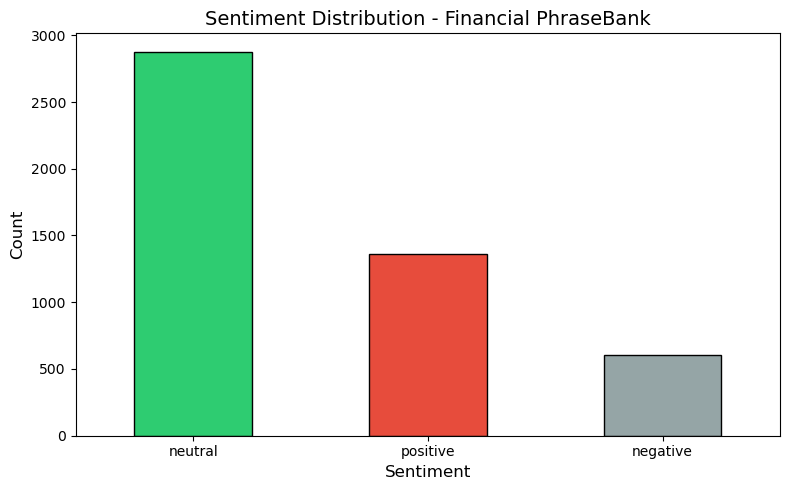

In [17]:
colors = ["#2ecc71", "#e74c3c", "#95a5a6"]
df["sentiment"].value_counts().plot(
    kind="bar",
    color=colors,
    edgecolor="black",
    figsize=(8, 5)
)
plt.title("Sentiment Distribution - Financial PhraseBank", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(r"C:\Users\gdevi\OneDrive\Documents\Devi's\projects\sentiment_distribution.png", dpi=150)
plt.show()

In [18]:
df.to_csv(r"C:\Users\gdevi\OneDrive\Documents\Devi's\projects\financial_dataset_clean.csv", index=False)
print("Clean dataset saved.")

Clean dataset saved.


In [21]:
!pip install yfinance

In [23]:
import yfinance as yf
import pandas as pd

In [24]:
stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

stock.columns = [col[0] if isinstance(col, tuple) else col for col in stock.columns]

stock["Price_Up"] = (stock["Close"].shift(-1) > stock["Close"]).astype(int)

stock.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [25]:
print("Shape:", stock.shape)
print("\nFirst 5 rows:")
print(stock.head())

Shape: (1006, 6)

First 5 rows:
                Close       High        Low       Open     Volume  Price_Up
Date                                                                       
2020-01-02  72.333893  72.394101  71.091199  71.344069  135480400         0
2020-01-03  71.630646  72.389265  71.406674  71.563213  146322800         1
2020-01-06  72.201401  72.239935  70.503539  70.754006  118387200         0
2020-01-07  71.861847  72.466330  71.642689  72.211049  108872000         1
2020-01-08  73.017845  73.318885  71.565629  71.565629  132079200         1


In [79]:
stock.to_csv(r"C:\Users\gdevi\OneDrive\Documents\Devi's\projects\aapl_stock_prices.csv")
print("\n Stock data saved.")


 Stock data saved.


In [1]:
!pip install transformers torch

  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   -- ------------------------------------- 0.8/10.8 MB 3.4 MB/s eta 0:00:03
   ---- ----------------------------------- 1.3/10.8 MB 3.4 MB/s eta 0:00:03
   ------- -------------------------------- 2.1/10.8 MB 3.0 MB/s eta 0:00:03
   --------- ------------------------------ 2.6/10.8 MB 3.1 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/10.8 MB 3.1 MB/s eta 0:00:03
   -------------- ------------------------- 3.9/10.8 MB 3.1 MB/s eta 0:00:03
   ----------------- ---------------------- 4.7/10.8 MB 3.2 MB/s eta 0:00:02
   ------------------- -------------------- 5.2/10.8 MB 3.1 MB/s eta 0:00:02
   --------------------- ------------------ 5.8/10.8 MB 3.1 MB/s eta 0:00:02
   ----------------------- ---------------- 6.3/10.8 MB 2.9 MB/s eta 0:00:02
   ------------------------- -------------- 6.8/10.8 MB 2.9 MB/s eta 0:00:02
   ----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.


In [27]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import pandas as pd

# FinBERT mode
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
model = BertForSequenceClassification.from_pretrained("ProsusAI/finbert")
model.eval()

print("FinBERT loaded successfully!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded successfully!


In [33]:
import pandas as pd

df = pd.read_csv(r"C:\Users\gdevi\OneDrive\Documents\Devi's\projects\financial_dataset_clean.csv")
print(f"Loaded! Shape: {df.shape}")

Loaded! Shape: (4837, 2)


In [37]:
# Function to get sentiment score for a headline
def get_finbert_sentiment(headline):
    inputs = tokenizer(headline, return_tensors="pt", max_length=512, truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    scores = torch.softmax(outputs.logits, dim=1).numpy()[0]
    labels = ["positive", "negative", "neutral"]
    return labels[scores.argmax()], round(float(scores.max()), 4)

# Test on a few headlines first
sample = df["headline"].sample(5, random_state=42).values

for headline in sample:
    label, score = get_finbert_sentiment(headline)
    print(f" {headline[:80]}...")
    print(f"   → {label.upper()} (confidence: {score})\n")

 The company serves customers in various industries , including process and resou...
   → NEUTRAL (confidence: 0.9449)

 Only L+ï¿½nnen Tehtaat showed a loss , but it has only recently started streamli...
   → NEUTRAL (confidence: 0.4909)

 The extracted filtrates are very high in clarity while the dried filter cakes me...
   → NEUTRAL (confidence: 0.8599)

 Thus , SysOpen Digia has , in accordance with Chapter 14 Section 21 of the Finni...
   → NEUTRAL (confidence: 0.9203)

 In stead of being based on a soft drink , as is usual , the Teho energy drink is...
   → NEUTRAL (confidence: 0.9424)



In [41]:
from tqdm import tqdm
tqdm.pandas()

# Apply FinBERT to all headlines (this will take a few minutes)
print("Running FinBERT on all headlines... ")

results = df["headline"].progress_apply(lambda x: get_finbert_sentiment(x))

df["finbert_sentiment"] = [r[0] for r in results]
df["finbert_confidence"] = [r[1] for r in results]

print("\n Done!")
print(df[["headline", "finbert_sentiment", "finbert_confidence"]].head(10))


Running FinBERT on all headlines... ⏳


100%|██████████| 4837/4837 [06:59<00:00, 11.54it/s]


 Done!
                                            headline finbert_sentiment  \
0  Technopolis plans to develop in stages an area...           neutral   
1  The international electronic industry company ...          negative   
2  With the new production plant the company woul...          positive   
3  According to the company 's updated strategy f...          positive   
4  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...          positive   
5  For the last quarter of 2010 , Componenta 's n...          positive   
6  In the third quarter of 2010 , net sales incre...          positive   
7  Operating profit rose to EUR 13.1 mn from EUR ...          positive   
8  Operating profit totalled EUR 21.1 mn , up fro...          positive   
9  TeliaSonera TLSN said the offer is in line wit...          positive   

   finbert_confidence  
0              0.5338  
1              0.9721  
2              0.9479  
3              0.8597  
4              0.8736  
5              0.9482  
6        

Original Sentiment Distribution:
sentiment
neutral     2871
positive    1362
negative     604
Name: count, dtype: int64

FinBERT Sentiment Distribution:
finbert_sentiment
neutral     2561
positive    1547
negative     729
Name: count, dtype: int64

 FinBERT Accuracy: 88.98%


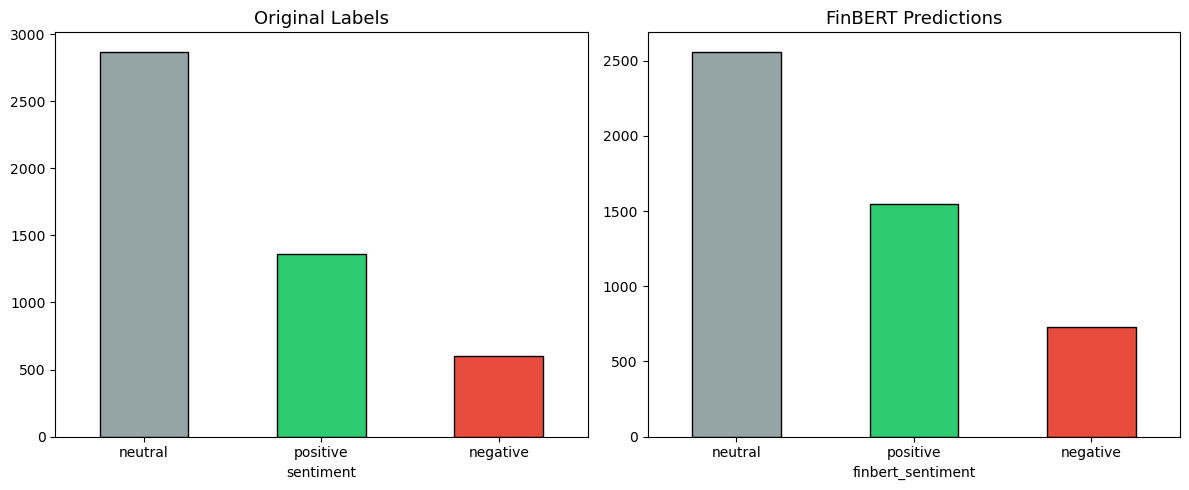

 Dataset saved with FinBERT scores!


In [43]:
import matplotlib.pyplot as plt

# Compare original vs FinBERT sentiment
print("Original Sentiment Distribution:")
print(df["sentiment"].value_counts())

print("\nFinBERT Sentiment Distribution:")
print(df["finbert_sentiment"].value_counts())

# Accuracy - how often does FinBERT agree with original labels
accuracy = (df["sentiment"] == df["finbert_sentiment"]).mean()
print(f"\n FinBERT Accuracy: {accuracy:.2%}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df["sentiment"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#95a5a6", "#2ecc71", "#e74c3c"], edgecolor="black"
)
axes[0].set_title("Original Labels", fontsize=13)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

df["finbert_sentiment"].value_counts().plot(
    kind="bar", ax=axes[1], color=["#95a5a6", "#2ecc71", "#e74c3c"], edgecolor="black"
)
axes[1].set_title("FinBERT Predictions", fontsize=13)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(r"C:\Users\gdevi\OneDrive\Documents\Devi's\projects\finbert_comparison.png", dpi=150)
plt.show()

# Save updated dataset
df.to_csv(r"C:\Users\gdevi\OneDrive\Documents\Devi's\projects\financial_dataset_clean.csv", index=False)
print(" Dataset saved with FinBERT scores!")